# CSV content analysis

- number of URLs in the content
- number of dates in the content
- number of numeric values in the content
- the 100 most frequent words in the content
- a plot of the 10,000 most frequent words

In [16]:
from pathlib import Path
import re
from collections import Counter
import time

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

## 1. Set the CSV path
Change the path below so it points to your CSV file.

In [17]:
CSV_PATH = Path(r"C:\Users\jespe\GDS eksamen\995,000_rows.csv")
CONTENT_COLUMN = "content"
ENCODING = "utf-8"
CHUNK_SIZE = 500000  # Process 500K rows at a time

## 2. Validate CSV header
This checks that the file is readable and that the target column exists, without loading the full dataset.

In [18]:
header_df = pd.read_csv(CSV_PATH, encoding=ENCODING, nrows=0)

if CONTENT_COLUMN not in header_df.columns:
    raise ValueError(
        f"Column '{CONTENT_COLUMN}' was not found. Available columns: {list(header_df.columns)}"
    )

print(f"CSV is readable: {CSV_PATH}")
print(f"Detected columns: {list(header_df.columns)}")
print(f"Using chunk size: {CHUNK_SIZE:,} rows")

CSV is readable: C:\Users\jespe\GDS eksamen\995,000_rows.csv
Detected columns: ['Unnamed: 0', 'id', 'domain', 'type', 'url', 'content', 'scraped_at', 'inserted_at', 'updated_at', 'title', 'authors', 'keywords', 'meta_keywords', 'meta_description', 'tags', 'summary', 'source']
Using chunk size: 500,000 rows


## 3. Regex patterns

These patterns are practical defaults:

- **URL pattern**: matches `http://`, `https://`, and `www.`
- **Date pattern**: matches common formats such as:
  - `2024-03-11`
  - `11-03-2024`
  - `11/03/2024`
  - `March 11, 2024`
- **Numeric pattern**: matches integers, decimals, and signed values

In [19]:
URL_PATTERN = re.compile(
    r"\b(?:https?://|www\.)[^\s<>'\"()]+",
    flags=re.IGNORECASE
)

DATE_PATTERN = re.compile(
    r"\b(?:"
    r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}"
    r"|"
    r"\d{4}[/-]\d{1,2}[/-]\d{1,2}"
    r"|"
    r"(?:jan|feb|mar|apr|may|jun|jul|aug|sep|sept|oct|nov|dec)"
    r"[a-z]*\s+\d{1,2},?\s+\d{2,4}"
    r")\b",
    flags=re.IGNORECASE
)

NUMERIC_PATTERN = re.compile(
    r"(?<!\w)[+-]?(?:\d+(?:[.,]\d+)?)(?!\w)"
)

WORD_PATTERN = re.compile(r"\b[a-zA-ZÀ-ÿ']+\b")

## 4. Stream through CSV and aggregate counts
This processes the file chunk-by-chunk to avoid loading the full dataset into memory.

In [20]:
start_time = time.time()
print(f"Starting DuckDB processing at {time.strftime('%H:%M:%S')}\n")

# Create DuckDB connection with memory limit
con = duckdb.connect()
con.execute("SET memory_limit='8GB'")
con.execute("SET threads=8")

print("Step 1: Counting total rows...")
scan_start = time.time()

# Query directly without creating table to save memory
total_rows = con.execute(f"""
    SELECT COUNT(*) 
    FROM read_csv_auto('{str(CSV_PATH)}', 
                       sample_size=50000,
                       parallel=true,
                       strict_mode=false,
                       ignore_errors=true)
    WHERE content IS NOT NULL
""").fetchone()[0]

print(f"  ✓ Total rows: {total_rows:,} (scanned in {time.time() - scan_start:.1f}s)\n")

# Step 2: Count URLs, dates, and numeric values - stream without loading into table
print("Step 2: Counting URLs, dates, and numeric values...")
regex_start = time.time()

url_pattern = r'https?://[^\s<>''\"()]+|www\.[^\s<>''\"()]+' 
date_pattern = r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}'
numeric_pattern = r'\b\d+\.?\d*\b'

# Stream and count in one pass
result = con.execute(f"""
    SELECT 
        SUM(LENGTH(regexp_extract_all(content, '{url_pattern}', 0))) as total_urls,
        SUM(LENGTH(regexp_extract_all(content, '{date_pattern}', 0))) as total_dates,
        SUM(LENGTH(regexp_extract_all(content, '{numeric_pattern}', 0))) as total_numeric
    FROM read_csv_auto('{str(CSV_PATH)}', 
                       sample_size=50000,
                       parallel=true,
                       strict_mode=false,
                       ignore_errors=true)
    WHERE content IS NOT NULL
""").fetchone()

total_urls = result[0] if result[0] else 0
total_dates = result[1] if result[1] else 0
total_numeric = result[2] if result[2] else 0

print(f"  ✓ Done in {time.time() - regex_start:.1f}s")
print(f"    - URLs: {total_urls:,}")
print(f"    - Dates: {total_dates:,}")
print(f"    - Numeric: {total_numeric:,}\n")

# Step 3: Extract and count words in chunks
print("Step 3: Extracting and counting words...")
print("  (Processing in chunks to manage memory...)")
word_start = time.time()

word_counts = Counter()
chunk_size = 500000

for offset in range(0, total_rows, chunk_size):
    chunk_start_time = time.time()
    
    # Stream words from CSV chunk
    words_df = con.execute(f"""
        SELECT regexp_extract_all(LOWER(content), '[a-zA-ZÀ-ÿ'']+', 0) as words
        FROM read_csv_auto('{str(CSV_PATH)}', 
                           sample_size=50000,
                           parallel=true,
                           strict_mode=false,
                           ignore_errors=true)
        WHERE content IS NOT NULL
        LIMIT {chunk_size} OFFSET {offset}
    """).fetchdf()
    
    # Count words - handle arrays properly
    for word_list in words_df['words']:
        if word_list is not None and len(word_list) > 0:
            word_counts.update(word_list)
    
    processed = min(offset + chunk_size, total_rows)
    elapsed = time.time() - word_start
    remaining = (elapsed / processed) * (total_rows - processed) / 60 if processed > 0 else 0
    
    print(f"    - Processed {processed:,}/{total_rows:,} rows ({processed/total_rows*100:.1f}%) "
          f"in {elapsed:.1f}s - Est. remaining: {remaining:.1f} min")
    
    del words_df

print(f"  ✓ Word counting complete in {time.time() - word_start:.1f}s\n")

# Step 4: Create preview
print("Step 4: Creating preview...")
preview_df = con.execute(f"""
    SELECT 
        content,
        LENGTH(regexp_extract_all(content, '{url_pattern}', 0)) as url_count,
        LENGTH(regexp_extract_all(content, '{date_pattern}', 0)) as date_count,
        LENGTH(regexp_extract_all(content, '{numeric_pattern}', 0)) as numeric_count
    FROM read_csv_auto('{str(CSV_PATH)}', 
                       sample_size=50000,
                       parallel=true,
                       strict_mode=false,
                       ignore_errors=true)
    WHERE content IS NOT NULL
    LIMIT 5
""").fetchdf()

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"PROCESSING COMPLETE!")
print(f"{'='*60}")
print(f"Total rows processed: {total_rows:,}")
print(f"Total time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Average speed: {total_rows/total_time:.0f} rows/second")
print(f"{'='*60}\n")

# Close connection
con.close()

preview_df

Starting DuckDB processing at 19:04:31

Step 1: Counting total rows...


<>:29: SyntaxWarning: invalid escape sequence '\.'
<>:29: SyntaxWarning: invalid escape sequence '\.'
C:\Users\jespe\AppData\Local\Temp\ipykernel_9108\1108022216.py:29: SyntaxWarning: invalid escape sequence '\.'
  url_pattern = r'https?://[^\s<>''\"()]+|www\.[^\s<>''\"()]+'


  ✓ Total rows: 995,058 (scanned in 3.8s)

Step 2: Counting URLs, dates, and numeric values...
  ✓ Done in 7.1s
    - URLs: 269,539
    - Dates: 83,929
    - Numeric: 9,246,055

Step 3: Extracting and counting words...
  (Processing in chunks to manage memory...)
    - Processed 500,000/995,058 rows (50.2%) in 179.3s - Est. remaining: 3.0 min
    - Processed 995,058/995,058 rows (100.0%) in 538.9s - Est. remaining: 0.0 min
  ✓ Word counting complete in 602.3s

Step 4: Creating preview...

PROCESSING COMPLETE!
Total rows processed: 995,058
Total time: 10.2 minutes (0.17 hours)
Average speed: 1618 rows/second



,content,url_count,date_count,numeric_count
0,Plus one article on Google Plus\n\n(Thanks to ...,0,0,2
1,The Cost Of The Best Senate Banking Committee ...,0,0,5
2,Man Awoken From 27-Year Coma Commits Suicide A...,0,0,2
3,WHEN Julia Geist was asked to draw a picture o...,0,0,7
4,– 100 Compiled Studies on Vaccine Dangers (Act...,0,0,995


## 5. Show total counts for the whole dataset

In [21]:
print(f"Total URLs found: {total_urls:,}")
print(f"Total dates found: {total_dates:,}")
print(f"Total numeric values found: {total_numeric:,}")

Total URLs found: 269,539
Total dates found: 83,929
Total numeric values found: 9,246,055


## 6. Find the 100 most frequent words in the content

Word frequencies were aggregated during chunked processing above.

In [22]:
top_100_words = word_counts.most_common(100)
top_100_df = pd.DataFrame(top_100_words, columns=["word", "count"])

top_100_df

,word,count
0,the,26197217
1,to,12665105
2,of,12497559
3,and,11515006
4,a,10016572
5,in,8722310
6,that,5601978
7,is,5073471
8,for,4386815
9,on,3522241


In [23]:
pd.set_option('display.max_rows', 100)
print(top_100_df)

          word     count
0          the  26197217
1           to  12665105
2           of  12497559
3          and  11515006
4            a  10016572
5           in   8722310
6         that   5601978
7           is   5073471
8          for   4386815
9           on   3522241
10          it   3357914
11           s   3324067
12        with   2834158
13          as   2804255
14         was   2446471
15         are   2444393
16          by   2344952
17           i   2291734
18        this   2281746
19          at   2198249
20          be   2176130
21         not   2114237
22          he   2109271
23         you   2100645
24        have   2099335
25        from   2043114
26          an   1723904
27         has   1709606
28        they   1676544
29         but   1647773
30         his   1632199
31          we   1602266
32          or   1534999
33        said   1415584
34         who   1347082
35        will   1334122
36       their   1269816
37         all   1192059
38        more   1160934


## 7. Plot the frequency of the 10,000 most frequent words

Because frequencies usually drop very quickly, the y-axis is shown on a logarithmic scale.

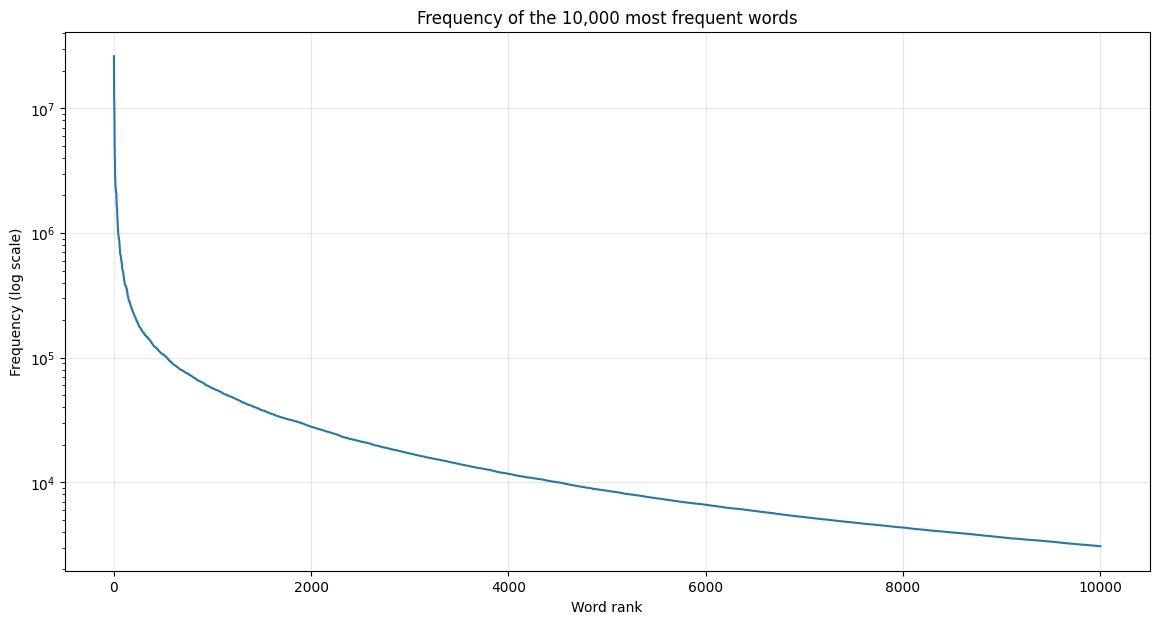

In [24]:
top_10000 = word_counts.most_common(10000)

freq_values = [count for _, count in top_10000]
ranks = range(1, len(freq_values) + 1)

plt.figure(figsize=(14, 7))
plt.plot(ranks, freq_values)
plt.yscale("log")
plt.xlabel("Word rank")
plt.ylabel("Frequency (log scale)")
plt.title("Frequency of the 10,000 most frequent words")
plt.grid(True, alpha=0.3)
plt.show()